# Diferencias entre Regresión y Clasificación

En esta clase aprenderemos a diferenciar entre los problemas de **regresión** y **clasificación**, así como los modelos y métricas más usados para evaluar un modelo de clasificación.  

---

## 🔹¿Por qué no podríamos usar un modelo de Regresión para clasificar?

- La **regresión** busca predecir valores **continuos** (ejemplo: precio de una casa, temperatura, ingresos).
- La **clasificación** busca asignar **etiquetas o categorías** (ejemplo: aprobar/reprobar, spam/no spam, perro/gato).
- Problema de usar regresión para clasificar:
  - El modelo entrega un número real (ej. 2.7, 5.1), que no representa directamente una clase.
  - Se podría forzar un umbral (ej. > 0.5 = clase 1, < 0.5 = clase 0), pero:
    - ❌ No funciona bien en problemas multiclase.
    - ❌ No optimiza métricas de clasificación (precisión, recall).
    - ❌ Los supuestos de regresión no se cumplen.

👉 Por eso existen **modelos de clasificación específicos** que aprenden a separar categorías.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = sns.load_dataset('titanic')
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [3]:
cols = ['pclass','sex','age','fare']
df = df[cols + ['survived']].dropna()
df.dtypes

,0
pclass,int64
sex,object
age,float64
fare,float64
survived,int64


In [4]:
df['sex'] = df['sex'].map({'male':0,'female':1})
df

,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0
...,...,...,...,...,...
885,3,1,39.0,29.1250,0
886,2,0,27.0,13.0000,0
887,1,1,19.0,30.0000,1
889,1,0,26.0,30.0000,1


# TRATA DE RESOLVER CON REGRESION LINEAL

In [5]:
X = df[cols]
y = df['survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
# Reshape y_train to be 2D before scaling
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1))

In [7]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

# Print the coefficients
print("Coefficients:", linear_model.coef_)

Coefficients: [[-0.33792214  0.49376307 -0.18839046 -0.00722931]]


In [8]:
# Make predictions using the linear regression model on the test data
y_pred = linear_model.predict(X_test)

# Display the first few predictions
print("First 10 predictions from Linear Regression model:")
print(y_pred[:10])

First 10 predictions from Linear Regression model:
[[ -8.68222454]
 [ -1.37656518]
 [ -5.83336652]
 [ -4.86652113]
 [ -9.16118517]
 [ -2.44864502]
 [ -6.85147301]
 [-10.52144005]
 [ -5.85201736]
 [ -4.91027616]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


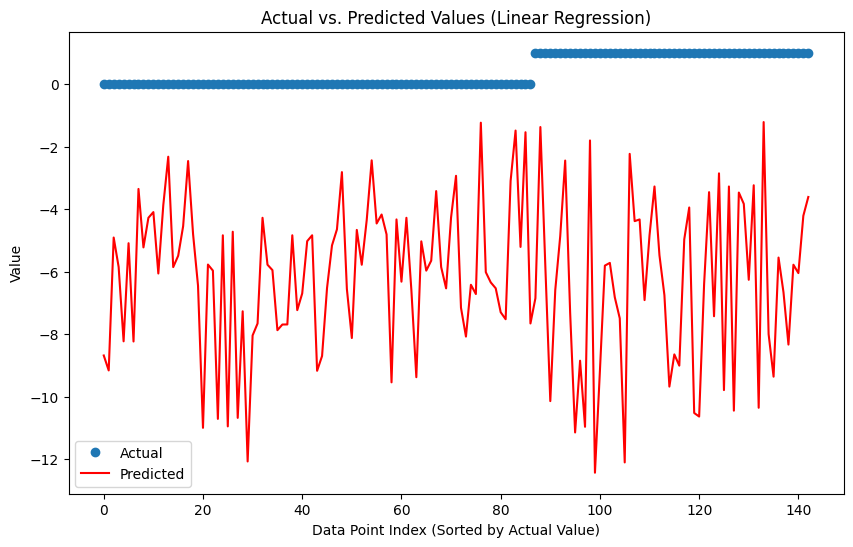

In [9]:
# Sort the test data for a clearer visualization
y_test_sorted = y_test.sort_values()
X_test_sorted = X_test.loc[y_test_sorted.index]
y_pred_sorted = linear_model.predict(X_test_sorted)


plt.figure(figsize=(10, 6))
plt.plot(y_test_sorted.values, label='Actual', marker='o', linestyle='')
plt.plot(y_pred_sorted, color='red', label='Predicted')
plt.title('Actual vs. Predicted Values (Linear Regression)')
plt.xlabel('Data Point Index (Sorted by Actual Value)')
plt.ylabel('Value')
plt.legend()
plt.show()

## 📈 Regresión Logística

La **regresión logística** es un algoritmo de clasificación que se utiliza para predecir la **probabilidad** de que una observación pertenezca a una de dos clases (binaria: 0 o 1). A diferencia de la regresión lineal, su salida no es continua, sino una probabilidad entre 0 y 1.

---

### 🔍 Fórmula General

Primero, se calcula una combinación lineal de las variables independientes:

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n
$$

Luego, esta combinación se transforma mediante la función **sigmoide** para obtener una probabilidad:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Donde:

- $\hat{y}$ es la probabilidad estimada de que la clase sea 1.  
- $e$ es la base del logaritmo natural.  
- $z$ es la salida de la regresión lineal.

---

### 📊 Interpretación

- Si $\hat{y} > 0.5$, se predice clase 1.  
- Si $\hat{y} \leq 0.5$, se predice clase 0.

---

In [10]:
X = df[cols]
y = df['survived']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

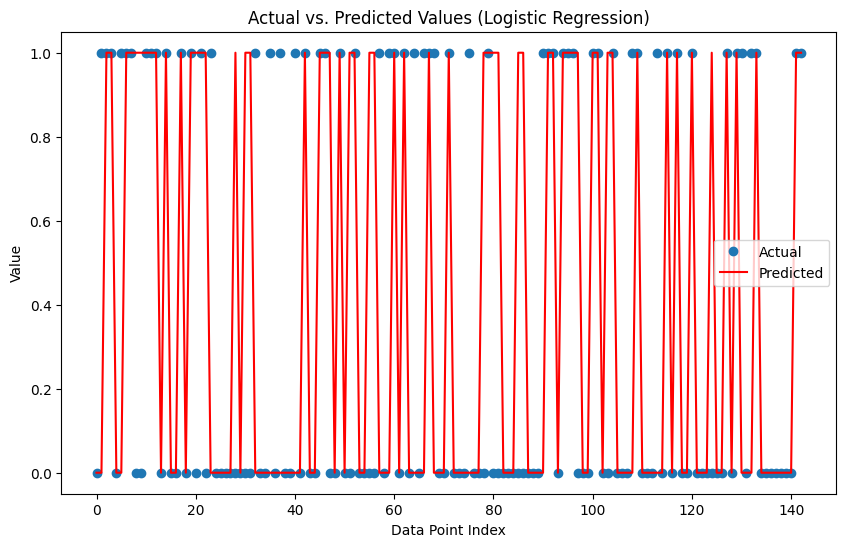

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='')
plt.plot(y_pred, color='red', label='Predicted')
plt.title('Actual vs. Predicted Values (Logistic Regression)')
plt.xlabel('Data Point Index')
plt.ylabel('Value')
plt.legend()
plt.show()

## 🔹¿Qué métricas se consideran para evaluar un modelo de clasificación?

- ✅ **Accuracy (Exactitud):** proporción de predicciones correctas.
- 📊 **F1-Score:** balance entre precisión y recall.
- 🟦 **Matriz de Confusión:** tabla de aciertos y errores.

👉 La métrica adecuada depende del contexto:
- Filtro de spam → más importante **recall**.  
- Diagnóstico médico → más importante **F1-score**.  
- Clasificación balanceada → **accuracy** puede ser suficiente.

## ✅ ¿Qué es el Accuracy?

El **accuracy** (o exactitud) es una métrica utilizada en problemas de **clasificación** para medir qué tan bien un modelo predice las clases correctas.

### 📌 Definición
El accuracy representa el **porcentaje de predicciones correctas** que hizo el modelo sobre el total de predicciones.

### 📘 Fórmula

$[
Accuracy = \frac{\text{Número de predicciones correctas}}{\text{Total de predicciones}}
$]

### 🧠 Interpretación
- **1.0 (100%)** → El modelo acertó todas las predicciones.  
- **0.0 (0%)** → El modelo falló todas.  
- **Valores cercanos a 1** → Mejor desempeño.  
- **Valores cercanos a 0.5** → El modelo predice casi al azar (para 2 clases).

### 📊 Ejemplo
Si el modelo hizo 100 predicciones y acertó 87:

$[
Accuracy = \frac{87}{100} = 0.87
$]

➡️ El modelo tiene **87% de exactitud**.


In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.74


## 📊 Matriz de Confusión

La **matriz de confusión** es una herramienta fundamental en la evaluación de modelos de **clasificación**.  
Permite visualizar claramente cómo se comportan las predicciones del modelo comparadas con los valores reales.

---

## 🧠 ¿Qué muestra?

Organiza las predicciones en una tabla que compara:

- **Filas** → Clases reales  
- **Columnas** → Clases predichas  

De esta forma podemos ver:
- Cuántas predicciones fueron correctas  
- Cuántas fueron incorrectas  
- En qué clase se confundió el modelo  

In [14]:
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix

array([[68, 19],
       [18, 38]])

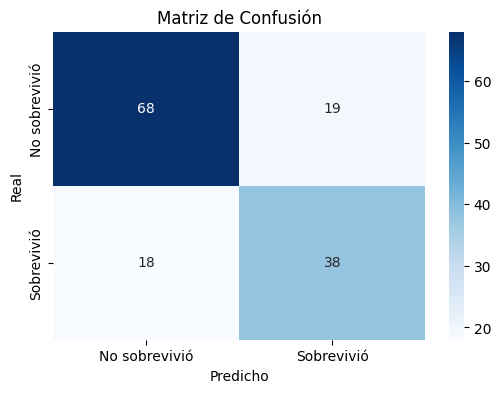

In [15]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()